> This work is done to answer the case based on the development of a dashboard for the Digital Gold product.

# Import Essentials

## Library

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset

> The dataset is randomly generated from an Excel file.

In [4]:
df = pd.read_excel('dataset/digital_gold_transaction.xlsx', sheet_name='Sheet3')
df.head()

,date,transaction_id,user_id,transaction_type,gold_price,sell_price,quantity,transaction_fee,total_sell_price,total_revenue,total_net_revenue
0,2020-01-20,DG0000000001,13,sell,900000,882000,8.21,72412.2,7313632.2,147780.0,75367.8
1,2020-01-23,DG0000000002,50,sell,900000,882000,2.84,25048.8,2529928.8,51120.0,26071.2
2,2020-02-01,DG0000000003,37,buy,900000,918000,1.29,11842.2,1196062.2,23220.0,11377.8
3,2020-02-06,DG0000000004,6,sell,900000,882000,5.43,47892.6,4837152.6,97740.0,49847.4
4,2020-02-25,DG0000000005,38,buy,900000,918000,8.08,74174.4,7491614.4,145440.0,71265.6


# Data Preparation

## Data Introduction

In [5]:
df.shape

(100, 11)

> This dataset has 100 rows with 11 columns each.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               100 non-null    datetime64[ns]
 1   transaction_id     100 non-null    object        
 2   user_id            100 non-null    int64         
 3   transaction_type   100 non-null    object        
 4   gold_price         100 non-null    int64         
 5   sell_price         100 non-null    int64         
 6   quantity           100 non-null    float64       
 7   transaction_fee    100 non-null    float64       
 8   total_sell_price   100 non-null    float64       
 9   total_revenue      100 non-null    float64       
 10  total_net_revenue  100 non-null    float64       
dtypes: datetime64[ns](1), float64(5), int64(3), object(2)
memory usage: 8.7+ KB


> Based on this information, it can be concluded that there is no need to deal with missing value since this dataset has no null and are all equal by count. However, it is still necessary to check the categorical variables to see if there is mistyped value.

## Review Categorical Data Entries

> To shorten the codes, a function will be made so that it can be reused later by only calling the function and insert the parameters needed.

In [7]:
def check_mistypedVal(col_names):
  for i, j in enumerate(col_names):
    print('==============================')
    print((i + 1), j)
    print(df[j].value_counts())

In [8]:
col_names = ['transaction_type']
check_mistypedVal(col_names)

1 transaction_type
transaction_type
sell    52
buy     48
Name: count, dtype: int64


> Based on this information, it can be concluded that this dataset is well distributed (balance) and there is no mistyped values in those categorical variables.

# Exploratory Data Analysis (EDA)

In [ ]:
def visualize(df, x, y, z, title, type):
  plt.figure(figsize=(20, 5))
  if (type == 'line'):
    plt.plot(df[x], df[y], marker='o')
  elif (type == 'grouped-line'):
    df = df.sort_values(y, ascending=False)
    sns.lineplot(x=x, y=y, hue=z, data=df)
  elif (type == 'bar'):
    df = df.sort_values(y, ascending=False).head(min(df[x].nunique(), 10))
    plt.bar(x, y, data=df.sort_values(y, ascending=False))
  elif (type == 'grouped-bar'):
    df = df.sort_values(y, ascending=False)
    sns.barplot(x=x, y=y, hue=z, data=df)
  else:
    df = df.sort_values(y, ascending=False).head(min(df[x].nunique(), 10))
    plt.pie(df[y], labels=df[x], autopct='%.2lf%%')
  plt.title(title)
  plt.xlabel(x)
  plt.ylabel(y)
  plt.show()

> There are many aspects that can be explored. However, only a few will be selected.

## Daily Trend by Transaction Types

In [28]:
eda_trend = df.groupby(['date', 'transaction_type'], as_index=False).agg({'transaction_id' : 'nunique', 'quantity' : 'sum', 'total_net_revenue' : 'sum'})
eda_trend.head()

,date,transaction_type,transaction_id,quantity,total_net_revenue
0,2020-01-20,sell,1,8.21,75367.8
1,2020-01-23,sell,1,2.84,26071.2
2,2020-02-01,buy,1,1.29,11377.8
3,2020-02-06,sell,1,5.43,49847.4
4,2020-02-25,buy,1,8.08,71265.6


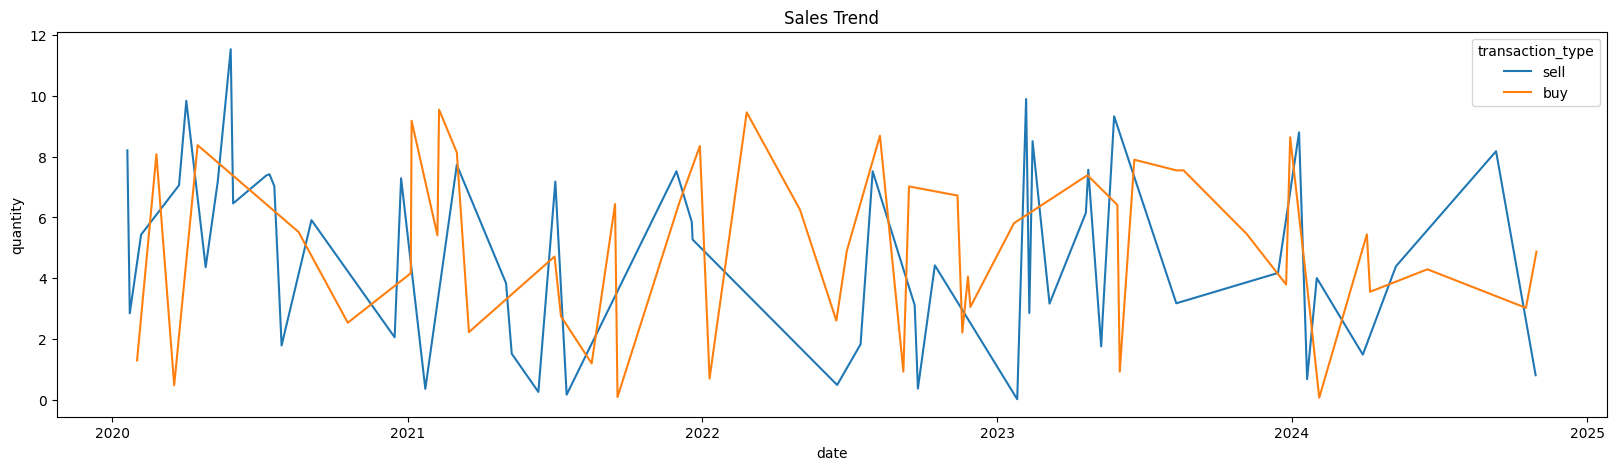

In [ ]:
visualize(eda_trend, 'date', 'quantity', 'transaction_type', 'Quantity Trend', 'grouped-line')

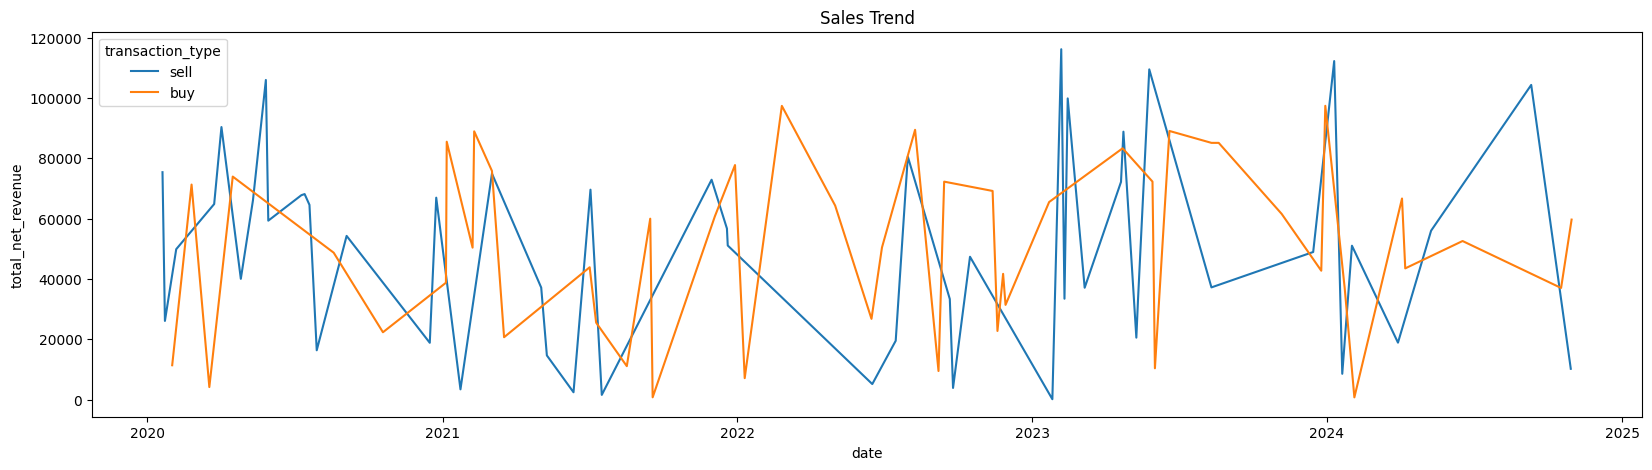

In [ ]:
visualize(eda_trend, 'date', 'total_net_revenue', 'transaction_type', 'Total Net Revenue Trend', 'grouped-line')

> Based on this information, it can be concluded that the sell and buy transactions these past years have been very dynamic, fluctuating significantly in both quantity and total net revenue. However, this randomly fluctuating graph might be because the dataset was generated randomly from Excel.

## Transaction Type Proportions

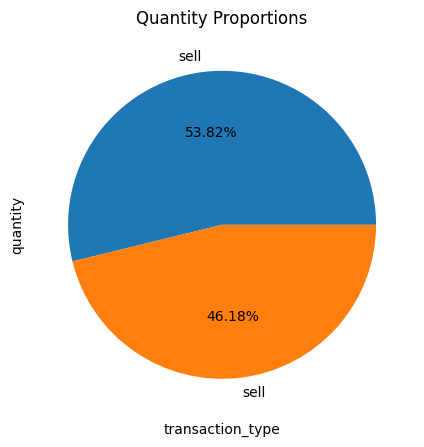

In [34]:
visualize(eda_trend, 'transaction_type', 'quantity', '', 'Quantity Proportions', 'pie')

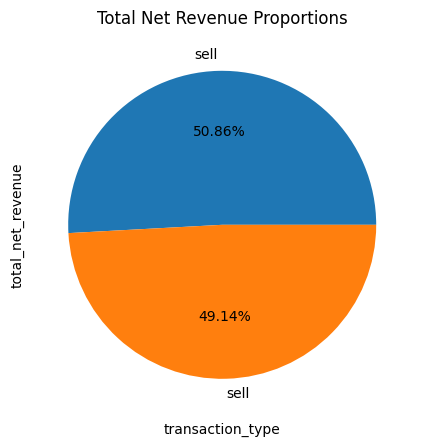

In [33]:
visualize(eda_trend, 'transaction_type', 'total_net_revenue', '', 'Total Net Revenue Proportions', 'pie')

> Based on this information, it can be concluded that both sell and buy transaction types have similar and fairly balanced quantities and total net revenue, suggesting that the digital gold transactions within this company/app are well-received due to these results. 

# Data Visualization

> Data Visualization will be conducted on Looker Studio/Google Data Studio and can be accessed by this link:
https://lookerstudio.google.com/reporting/a7ee7a18-e021-4e12-9ffd-e81ef3f41a70